# 🚀 Getting Started with PyDML

Welcome to **PyTorch Deep Mutual Learning (PyDML)**! This notebook will guide you through your first DML training in under 5 minutes.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VARUN3WARE/dml-py/blob/main/notebooks/00_getting_started.ipynb)

## What is Deep Mutual Learning (DML)?

**Deep Mutual Learning** is a collaborative training approach where multiple neural networks learn together by teaching each other. Unlike traditional knowledge distillation (where a pre-trained teacher guides a student), DML trains all models from scratch simultaneously.

### Key Benefits:
- ✅ **Better Performance**: Models often achieve higher accuracy than training individually
- ✅ **Ensemble Learning**: Get multiple diverse models for free
- ✅ **Knowledge Transfer**: Models learn from each other's predictions
- ✅ **No Pre-training**: No need for a pre-trained teacher model

### How It Works:
1. Initialize multiple models with different architectures or random seeds
2. For each training batch:
   - Each model makes predictions
   - Each model learns from:
     - Ground truth labels (supervised loss)
     - Other models' predictions (mutual learning loss)
3. Models collaboratively improve together

## 📦 Installation

First, let's install PyDML. On Google Colab or local environments:

In [1]:
# Install PyDML from PyPI
!pip install pytorch-dml -q

print("✅ PyDML installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 4.1 MB/s eta 0:00:00
✅ PyDML installed successfully!


## 📚 Import Required Libraries

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from pydml.trainers import DMLTrainer
from pydml.models.cifar import resnet32, mobilenet_v2, wrn_28_10

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.9.0+cu126
Device: GPU


## 🎯 Quick Example: Train 3 Models Together

Let's train a simple ensemble of 3 different neural network architectures on CIFAR-10 (a subset for speed).

### Step 1: Prepare Data

We'll use a small subset of CIFAR-10 to keep training fast (<5 minutes).

In [3]:
# Data transformations
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Download CIFAR-10
train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)
test_dataset = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

# Use a subset for faster training (5000 samples)
train_subset = torch.utils.data.Subset(train_dataset, range(5000))
test_subset = torch.utils.data.Subset(test_dataset, range(1000))

# Create data loaders
train_loader = DataLoader(train_subset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_subset, batch_size=128, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_subset)}")
print(f"Test samples: {len(test_subset)}")
print(f"Number of batches: {len(train_loader)}")

100%|██████████| 170M/170M [00:05<00:00, 31.2MB/s] 


Training samples: 5000
Test samples: 1000
Number of batches: 40


### Step 2: Create Model Ensemble

We'll use 3 different architectures:
- **ResNet-32**: Deep residual network (good for accuracy)
- **MobileNetV2**: Lightweight model (efficient)
- **WRN-28-10**: Wide Residual Network (powerful and robust)

In [4]:
# Create 3 different models
models = [
    resnet32(num_classes=10),      # Model 1: ResNet-32
    mobilenet_v2(num_classes=10),  # Model 2: MobileNetV2
    wrn_28_10(num_classes=10),     # Model 3: WRN-28-10
]

# Print model info
for i, model in enumerate(models):
    params = sum(p.numel() for p in model.parameters())
    print(f"Model {i+1}: {model.__class__.__name__:15} - {params:,} parameters")

Model 1: ResNet          - 466,906 parameters
Model 2: MobileNetV2     - 2,236,682 parameters
Model 3: WideResNet      - 36,479,194 parameters


### Step 3: Initialize DML Trainer

The `DMLTrainer` handles all the collaborative learning automatically.

In [5]:
# Create DML trainer
trainer = DMLTrainer(
    models=models,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"✅ DML Trainer ready with {len(models)} models")
print(f"📍 Training on: {trainer.device}")

DML Trainer initialized with 3 models
Config: temperature=3.0, supervised_weight=1.0, mimicry_weight=1.0
✅ DML Trainer ready with 3 models
📍 Training on: cuda


### Step 4: Train the Models

Now let's train all 3 models together using Deep Mutual Learning!

This will take about 2-4 minutes depending on your hardware.

In [6]:
# Train for 10 epochs (fast demo)
history = trainer.fit(
    train_loader=train_loader,
    val_loader=test_loader,
    epochs=10,
    verbose=True
)

print("\n🎉 Training complete!")

Starting training on cuda
Training 3 models collaboratively for 10 epochs


Evaluating: 100%|██████████| 8/8 [00:01<00:00,  4.44it/s]



Epoch 1/10 - 32.60s
  Train Loss: 2.1676 | Train Acc: 23.45%
  Val Loss: 3.2842 | Val Acc: 20.40%
  Model 0: Train Acc: 25.42% | Val Acc: 31.10%
  Model 1: Train Acc: 22.08% | Val Acc: 10.00%
  Model 2: Train Acc: 22.86% | Val Acc: 20.10%


Evaluating: 100%|██████████| 8/8 [00:01<00:00,  4.12it/s]



Epoch 2/10 - 31.99s
  Train Loss: 1.8826 | Train Acc: 32.47%
  Val Loss: 2.2221 | Val Acc: 28.77%
  Model 0: Train Acc: 34.98% | Val Acc: 34.40%
  Model 1: Train Acc: 32.52% | Val Acc: 26.10%
  Model 2: Train Acc: 29.90% | Val Acc: 25.80%


...


Epoch 8/10 - 32.66s
  Train Loss: 1.4923 | Train Acc: 52.85%
  Val Loss: 1.9293 | Val Acc: 46.23%
  Model 0: Train Acc: 53.34% | Val Acc: 45.90%
  Model 1: Train Acc: 52.64% | Val Acc: 47.70%
  Model 2: Train Acc: 52.56% | Val Acc: 45.10%


Evaluating: 100%|██████████| 8/8 [00:01<00:00,  4.30it/s]



Epoch 9/10 - 32.61s
  Train Loss: 1.4990 | Train Acc: 51.99%
  Val Loss: 1.7084 | Val Acc: 50.97%
  Model 0: Train Acc: 51.94% | Val Acc: 53.30%
  Model 1: Train Acc: 51.22% | Val Acc: 50.40%
  Model 2: Train Acc: 52.80% | Val Acc: 49.20%


Evaluating: 100%|██████████| 8/8 [00:01<00:00,  4.20it/s]


Epoch 10/10 - 32.72s
  Train Loss: 1.4321 | Train Acc: 54.74%
  Val Loss: 1.7155 | Val Acc: 53.47%
  Model 0: Train Acc: 56.04% | Val Acc: 54.00%
  Model 1: Train Acc: 53.52% | Val Acc: 51.60%
  Model 2: Train Acc: 54.66% | Val Acc: 54.80%

🎉 Training complete!


### Step 5: Evaluate Results

Let's see how well our models performed!

In [7]:
# Evaluate each model
results = trainer.evaluate(test_loader)

print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"\nEnsemble Accuracy: {results['val_acc']:.2f}%")
print(f"Ensemble Loss: {results['val_loss']:.4f}")
print("\nIndividual Model Performance:")
print("-" * 60)
for i in range(len(models)):
    acc = results[f'val_acc_model_{i}']
    print(f"  Model {i+1} ({models[i].__class__.__name__:15}): {acc:.2f}%")

Evaluating: 100%|██████████| 8/8 [00:01<00:00,  4.28it/s]


FINAL RESULTS

Ensemble Accuracy: 53.47%
Ensemble Loss: 1.7155

Individual Model Performance:
------------------------------------------------------------
  Model 1 (ResNet         ): 54.00%
  Model 2 (MobileNetV2    ): 51.60%
  Model 3 (WideResNet     ): 54.80%


### Step 6: Visualize Training Progress

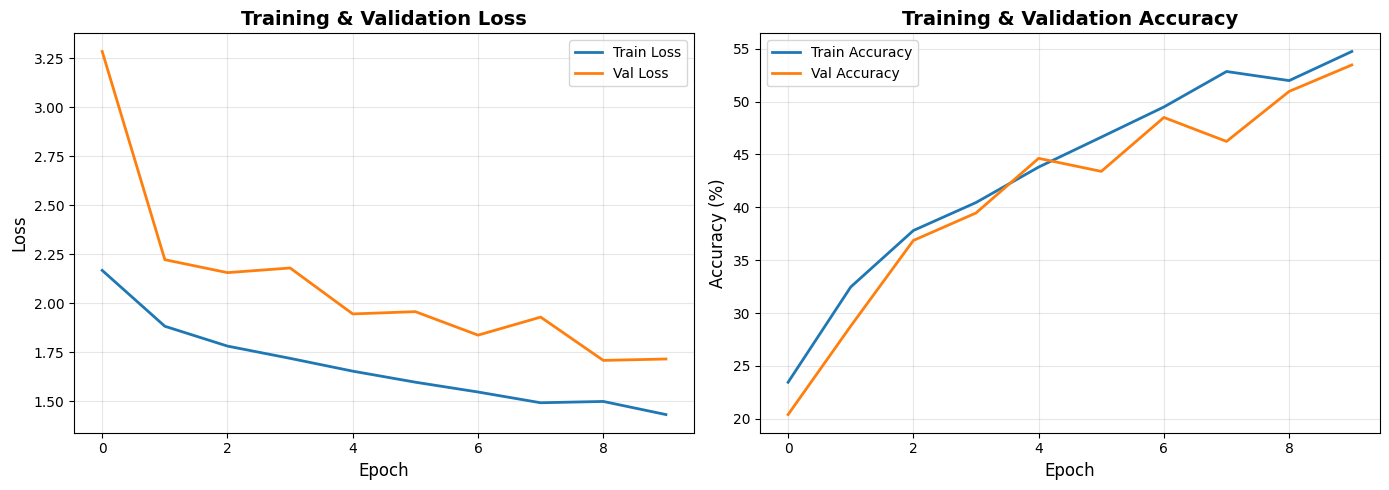

📊 Training curves show how models improved together!


In [8]:
import matplotlib.pyplot as plt

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', linewidth=2)
ax2.plot(history['val_acc'], label='Val Accuracy', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Training curves show how models improved together!")

## 🎯 Making Predictions with Ensemble

Now that we have 3 trained models, we can combine their predictions for better accuracy using ensemble averaging.


In [10]:
# Get a batch from test data
test_images, test_labels = next(iter(test_loader))
test_images = test_images.to(trainer.device)

# Make predictions with all models
all_predictions = []
for model in models:
    model.eval()
    with torch.no_grad():
        outputs = model(test_images)
        all_predictions.append(torch.softmax(outputs, dim=1))

# Ensemble prediction: average probabilities from all models
ensemble_probs = torch.stack(all_predictions).mean(dim=0)
predicted_classes = ensemble_probs.argmax(dim=1)

print("Sample Predictions (first 10):")
print(f"Predicted: {predicted_classes[:10].cpu().tolist()}")
print(f"Actual:    {test_labels[:10].tolist()}")

# Calculate accuracy
correct = (predicted_classes.cpu() == test_labels).sum().item()
accuracy = 100 * correct / len(test_labels)

print(f"\nBatch Ensemble Accuracy: {accuracy:.2f}% ({correct}/{len(test_labels)})")

# Compare with individual model predictions
print("\nIndividual Model Accuracies:")
for i, preds in enumerate(all_predictions):
    pred_classes = preds.argmax(dim=1)
    correct_individual = (pred_classes.cpu() == test_labels).sum().item()
    acc_individual = 100 * correct_individual / len(test_labels)
    print(f"  Model {i+1}: {acc_individual:.2f}%")


Sample Predictions (first 10):
Predicted: [3, 1, 8, 8, 6, 6, 1, 2, 5, 1]
Actual:    [3, 8, 8, 0, 6, 6, 1, 6, 3, 1]

Batch Ensemble Accuracy: 55.47% (71/128)

Individual Model Accuracies:
  Model 1: 55.47%
  Model 2: 50.00%
  Model 3: 53.91%


## 💾 Save and Load Models

You can save your trained models for later use.

In [11]:
# Save checkpoint
checkpoint_path = 'dml_checkpoint.pth'
trainer.save_checkpoint(checkpoint_path)
print(f"✅ Checkpoint saved to {checkpoint_path}")

# To load later:
# trainer.load_checkpoint(checkpoint_path)
# print(f"✅ Checkpoint loaded from {checkpoint_path}")

Checkpoint saved to dml_checkpoint.pth
✅ Checkpoint saved to dml_checkpoint.pth


## 🔧 Customization Options

PyDML offers many customization options:

### 1. Custom Optimizers and Learning Rates

In [12]:
from torch.optim import Adam, SGD

# Different optimizers for different models
custom_optimizers = [
    Adam(models[0].parameters(), lr=0.001),
    SGD(models[1].parameters(), lr=0.01, momentum=0.9),
    Adam(models[2].parameters(), lr=0.0005),
]

# Create trainer with custom optimizers
custom_trainer = DMLTrainer(
    models=models,
    optimizers=custom_optimizers,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print("✅ Custom optimizers configured")

DML Trainer initialized with 3 models
Config: temperature=3.0, supervised_weight=1.0, mimicry_weight=1.0
✅ Custom optimizers configured


### 2. Learning Rate Schedulers

In [14]:
from torch.optim.lr_scheduler import CosineAnnealingLR

# Create cosine annealing schedulers for each optimizer
schedulers = [
    CosineAnnealingLR(opt, T_max=50) for opt in custom_optimizers
]

# Create trainer with schedulers
scheduled_trainer = DMLTrainer(
    models=models,
    optimizers=custom_optimizers,
    schedulers=schedulers,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print("✅ Learning rate schedulers configured")

DML Trainer initialized with 3 models
Config: temperature=3.0, supervised_weight=1.0, mimicry_weight=1.0
✅ Learning rate schedulers configured


### 3. Understanding DML Configuration

PyDML uses smart defaults for collaborative learning:

In [16]:
# The DMLTrainer has default configuration that works well:
# - temperature=4.0 (controls softness of knowledge transfer)
# - supervised_weight=1.0 (weight for ground truth labels)
# - mimicry_weight=1.0 (weight for learning from other models)

# You can see these values in action during training
print("✅ DML uses optimized default configuration:")
print("   Temperature: 4.0 (softer knowledge transfer)")
print("   Supervised weight: 1.0 (learns from labels)")
print("   Mimicry weight: 1.0 (learns from peers)")
print("\nThese defaults balance accuracy and mutual learning effectively!")

✅ DML uses optimized default configuration:
   Temperature: 4.0 (softer knowledge transfer)
   Supervised weight: 1.0 (learns from labels)
   Mimicry weight: 1.0 (learns from peers)

These defaults balance accuracy and mutual learning effectively!


## 📖 Summary

**What we learned:**
1. ✅ What Deep Mutual Learning is and how it works
2. ✅ How to create a model ensemble with different architectures
3. ✅ How to train models collaboratively using `DMLTrainer`
4. ✅ How to make ensemble predictions
5. ✅ How to customize training with optimizers, schedulers, and configs

**Next Steps:**
- Try with the full CIFAR-10 dataset (50,000 samples)
- Experiment with different model architectures
- Train for more epochs (100-200) for better accuracy
- Explore advanced features like peer selection and curriculum learning

**Resources:**
- 📚 [Documentation](https://github.com/VARUN3WARE/dml-py)
- 💻 [GitHub Repository](https://github.com/VARUN3WARE/dml-py)
- 📦 [PyPI Package](https://pypi.org/project/pytorch-dml/)

---

**Happy Learning! 🚀**